In [60]:
import pandas as pd
import os


In [61]:
BASE = os.path.join(os.getcwd(), "..")  # project root
sellers = pd.read_csv(os.path.join(BASE, "Data", "raw", "sellers.csv"))


In [62]:
#checking duplicates
dup_count = int(sellers.duplicated(subset="seller_id").sum())
#checking nulls
missing_val = sellers.isna().sum()
#Number of sellers
total_seller = sellers["seller_id"].nunique()

#checking the consistency of category and subcategory

uni_cat = list(sellers["primary_city"].unique())

#checking dtype
sellers.dtypes


seller_id           str
seller_name         str
primary_city        str
rating          float64
dtype: object

In [63]:
print(f"""
========================================
        SELLER TABLE SUMMARY
========================================
  Total Sellers     : {total_seller}
  number of Cities  : {len(uni_cat)}
  Duplicates        : {dup_count}
  Missing Values    : {missing_val.any()}
========================================
""")


        SELLER TABLE SUMMARY
  Total Sellers     : 400
  number of Cities  : 12
  Duplicates        : 0
  Missing Values    : False



In [64]:
# Are we over-dependent on sellers from one city?

seller_city = sellers.groupby("primary_city")["seller_id"].count().reset_index()
seller_city["pct"] = (seller_city["seller_id"] / seller_city["seller_id"].sum() * 100).round(2)
seller_city.sort_values("pct", ascending=False)

,primary_city,seller_id,pct
10,Mumbai,79,19.75
4,Delhi,64,16.00
1,Bangalore,52,13.00
5,Hyderabad,37,9.25
11,Pune,34,8.50
8,Kolkata,32,8.00
3,Chennai,32,8.00
6,Jaipur,17,4.25
0,Ahmedabad,15,3.75
9,Lucknow,14,3.50


In [65]:
sellers["rating"].max()

np.float64(5.0)

In [66]:
sellers["rating"].min()

np.float64(1.6)

In [67]:
sellers.loc[(sellers["rating"] >= 1) & (sellers["rating"] <= 2), "rating_bin"] = "Poor"
sellers.loc[(sellers["rating"] > 2) & (sellers["rating"] <= 3), "rating_bin"] = "Below Avg"
sellers.loc[(sellers["rating"] > 3) & (sellers["rating"] <= 4), "rating_bin"] = "Avg"
sellers.loc[(sellers["rating"] > 4) & (sellers["rating"] <= 5), "rating_bin"] = "Best"

In [68]:
# Which cities have the most poor and best rated sellers?


In [69]:
# Total sellers per city
total_by_city = sellers.groupby("primary_city")["seller_id"].count().reset_index()
total_by_city.columns = ["primary_city", "total_sellers"]

# Poor + Below Avg sellers per city
poor_by_city = (sellers[sellers["rating_bin"].isin(["Poor", "Below Avg"])]
                .groupby("primary_city")["seller_id"]
                .count()
                .reset_index())
poor_by_city.columns = ["primary_city", "poor_sellers(rating 1-2)"]

#best sellers by city

# Merge and calculate percentage
poor_concentration = (total_by_city
                      .merge(poor_by_city, on="primary_city", how="left")
                      .fillna(0))

poor_concentration["poor_pct"] = ((poor_concentration["poor_sellers(rating 1-2)"] / 
                                   poor_concentration["total_sellers"]) * 100).round(2)

#poor_concentration.sort_values("poor_pct", ascending=False)

In [70]:
best_perf = sellers[sellers["rating_bin"].isin(["Best"])] \
    .groupby("primary_city")["seller_id"] \
    .count() \
    .reset_index() \
    .rename({"seller_id": "best_performer(rating 4-5)"}, axis=1)

performance_rep = pd.merge(poor_concentration, best_perf,on="primary_city",how='left')
performance_rep["best_pct"] = (performance_rep["best_performer(rating 4-5)"]/performance_rep["total_sellers"]*100).round(2)

In [71]:
performance_rep.sort_values(by="total_sellers",ascending=False)

,primary_city,total_sellers,poor_sellers(rating 1-2),poor_pct,best_performer(rating 4-5),best_pct
10,Mumbai,79,11,13.92,32,40.51
4,Delhi,64,8,12.50,25,39.06
1,Bangalore,52,7,13.46,14,26.92
5,Hyderabad,37,5,13.51,18,48.65
11,Pune,34,5,14.71,13,38.24
8,Kolkata,32,3,9.38,16,50.00
3,Chennai,32,10,31.25,13,40.62
6,Jaipur,17,3,17.65,4,23.53
0,Ahmedabad,15,2,13.33,8,53.33
9,Lucknow,14,2,14.29,8,57.14


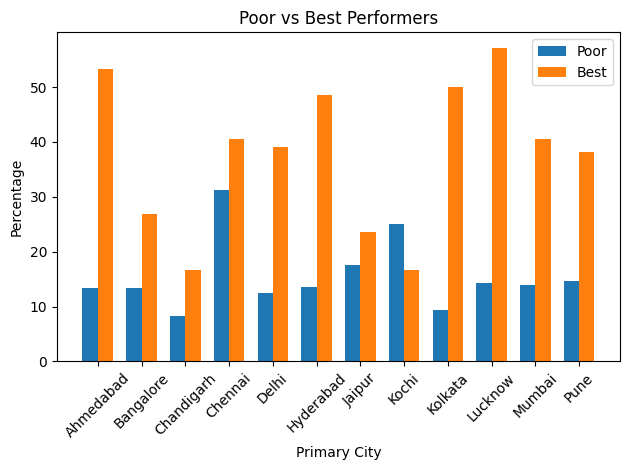

In [72]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(performance_rep))
width = 0.35

plt.bar(x - width/2, performance_rep["poor_pct"], width, label="Poor")
plt.bar(x + width/2, performance_rep["best_pct"], width, label="Best")

plt.xlabel("Primary City")
plt.ylabel("Percentage")
plt.title("Poor vs Best Performers")

plt.xticks(x, performance_rep["primary_city"], rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

In [73]:
to_path = os.path.join(BASE,"DATA","preprocessed")
sellers.to_parquet(f"{to_path}\sellers_clean.parquet")

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\naban\AppData\Local\Temp\ipykernel_13244\893395198.py:2: SyntaxWarning: invalid escape sequence '\s'
  sellers.to_parquet(f"{to_path}\sellers_clean.parquet")
